Number of pickup requests: 30
Number of vehicles: 5
Vehicle capacity: 8

Starting GA...

Generation   0 | Best =   822.80 | Current =   822.80 | Average =  1686.13
Generation  10 | Best =   797.40 | Current =   797.40 | Average =  1580.16
Generation  20 | Best =   788.50 | Current =   788.50 | Average =  1645.38
Generation  30 | Best =   788.50 | Current =   788.50 | Average =  1546.98
Generation  40 | Best =   788.50 | Current =   788.50 | Average =  1626.17
Generation  50 | Best =   788.50 | Current =   788.50 | Average =  1645.38
Generation  60 | Best =   710.30 | Current =   710.30 | Average =  1634.38
Generation  70 | Best =   710.30 | Current =   710.30 | Average =  1639.72
Generation  80 | Best =   710.30 | Current =   710.30 | Average =  1668.37
Generation  90 | Best =   710.30 | Current =   710.30 | Average =  1652.83
Generation 100 | Best =   710.30 | Current =   710.30 | Average =  1673.37
Generation 110 | Best =   710.30 | Current =   710.30 | Average =  1666.97
Generation 

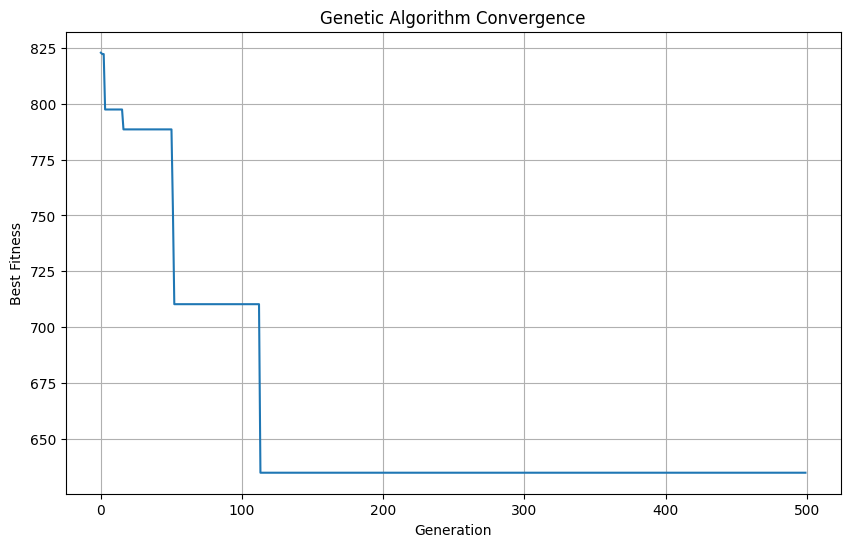

In [5]:
import random
import networkx as nx
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE A LARGER ROAD NETWORK
# ============================================================

def create_road_network():

    G = nx.grid_2d_graph(6, 6)

    # Convert (row, column) into simple names
    mapping = {}

    for node in G.nodes():
        mapping[node] = f"N{node[0]}_{node[1]}"

    G = nx.relabel_nodes(G, mapping)

    # Give every road a random distance
    for u, v in G.edges():

        G[u][v]["weight"] = random.randint(2, 10)

    return G


# ============================================================
# 2. CREATE 30 PICKUP REQUESTS
# ============================================================

def create_pickups(G, number_of_pickups=30):

    nodes = list(G.nodes())

    # Don't put passengers at the depot
    nodes.remove("N0_0")

    selected_nodes = random.sample(
        nodes,
        number_of_pickups
    )

    pickups = {}

    for i, node in enumerate(
        selected_nodes,
        start=1
    ):

        pickups[f"P{i}"] = {
            "node": node,

            # 1 or 2 passengers
            "demand": random.choice([1, 1, 1, 2])
        }

    return pickups


# ============================================================
# 3. GA PARAMETERS
# ============================================================

NUM_VEHICLES = 5

VEHICLE_CAPACITY = 8

POPULATION_SIZE = 100

GENERATIONS = 500

MUTATION_RATE = 0.20

ELITE_SIZE = 3

PENALTY_BETA = 160


# ============================================================
# 4. CREATE INITIAL CHROMOSOME
# ============================================================

def create_chromosome(pickup_ids):

    shuffled = pickup_ids.copy()

    random.shuffle(shuffled)

    routes = [
        []
        for _ in range(NUM_VEHICLES)
    ]

    # Randomly assign every passenger
    # to a vehicle.

    for pickup in shuffled:

        vehicle = random.randrange(
            NUM_VEHICLES
        )

        routes[vehicle].append(
            pickup
        )

    return routes


# ============================================================
# 5. CREATE POPULATION
# ============================================================

def create_population(pickup_ids):

    population = []

    for _ in range(POPULATION_SIZE):

        chromosome = create_chromosome(
            pickup_ids
        )

        # IMPORTANT:
        # Do NOT repair the initial population.
        #
        # We want the GA to initially contain
        # some bad solutions.
        #
        # The penalty function will punish them.

        population.append(
            chromosome
        )

    return population


# ============================================================
# 6. VEHICLE LOAD
# ============================================================

def vehicle_load(route, pickups):

    return sum(
        pickups[p]["demand"]
        for p in route
    )


# ============================================================
# 7. DISTANCE MATRIX USING DIJKSTRA
# ============================================================

def calculate_shortest_distances(
    G,
    pickups
):

    locations = {
        "DEPOT": "N0_0"
    }

    for pickup_id, data in pickups.items():

        locations[pickup_id] = data["node"]

    distance_matrix = {}

    for source_id, source_node in locations.items():

        distance_matrix[source_id] = {}

        distances = nx.single_source_dijkstra_path_length(
            G,
            source_node,
            weight="weight"
        )

        for target_id, target_node in locations.items():

            distance_matrix[source_id][target_id] = (
                distances[target_node]
            )

    return distance_matrix


# ============================================================
# 8. ROUTE DISTANCE
# ============================================================

def route_distance(
    route,
    distance_matrix
):

    if len(route) == 0:
        return 0

    distance = 0

    # DEPOT → first pickup

    distance += (
        distance_matrix["DEPOT"][route[0]]
    )

    # Pickup → pickup

    for i in range(len(route) - 1):

        current = route[i]

        next_pickup = route[i + 1]

        distance += (
            distance_matrix[current][next_pickup]
        )

    # Last pickup → DEPOT

    distance += (
        distance_matrix[route[-1]]["DEPOT"]
    )

    return distance


# ============================================================
# 9. FITNESS FUNCTION
# ============================================================

def fitness(
    chromosome,
    distance_matrix,
    pickups
):

    total_distance = 0

    capacity_penalty = 0

    route_lengths = []

    for vehicle in range(
        NUM_VEHICLES
    ):

        route = chromosome[vehicle]

        distance = route_distance(
            route,
            distance_matrix
        )

        total_distance += distance

        route_lengths.append(
            distance
        )

        # ----------------------------
        # Capacity constraint
        # ----------------------------

        load = vehicle_load(
            route,
            pickups
        )

        if load > VEHICLE_CAPACITY:

            overload = (
                load
                - VEHICLE_CAPACITY
            )

            capacity_penalty += (
                PENALTY_BETA
                * overload
            )

    # ----------------------------
    # Balance routes
    # ----------------------------

    longest_route = max(
        route_lengths
    )

    balance_penalty = (
        0.1 * longest_route
    )

    total_fitness = (
        total_distance
        + capacity_penalty
        + balance_penalty
    )

    return total_fitness


# ============================================================
# 10. RANK-BASED SELECTION
# ============================================================

def rank_selection(
    population,
    fitness_values
):

    ranked = sorted(
        zip(
            population,
            fitness_values
        ),
        key=lambda x: x[1]
    )

    chromosomes = [
        item[0]
        for item in ranked
    ]

    # Best = highest rank
    ranks = list(
        range(
            len(chromosomes),
            0,
            -1
        )
    )

    gamma = 1.5

    weights = [
        rank ** gamma
        for rank in ranks
    ]

    parent1 = random.choices(
        chromosomes,
        weights=weights,
        k=1
    )[0]

    parent2 = random.choices(
        chromosomes,
        weights=weights,
        k=1
    )[0]

    return parent1, parent2


# ============================================================
# 11. ORDER CROSSOVER
# ============================================================

def crossover(
    parent1,
    parent2
):

    # Convert routes to one list

    p1 = [
        pickup
        for route in parent1
        for pickup in route
    ]

    p2 = [
        pickup
        for route in parent2
        for pickup in route
    ]

    length = len(p1)

    # Select crossover points

    start, end = sorted(
        random.sample(
            range(length),
            2
        )
    )

    child = [
        None
        for _ in range(length)
    ]

    # Copy section from parent 1

    child[start:end] = p1[start:end]

    # Fill remaining positions
    # using parent 2 order

    remaining = [
        x
        for x in p2
        if x not in child
    ]

    index = 0

    for i in range(length):

        if child[i] is None:

            child[i] = remaining[index]

            index += 1

    # ---------------------------------
    # Randomly divide into vehicles
    # ---------------------------------

    new_routes = [
        []
        for _ in range(NUM_VEHICLES)
    ]

    for pickup in child:

        vehicle = random.randrange(
            NUM_VEHICLES
        )

        new_routes[vehicle].append(
            pickup
        )

    return new_routes


# ============================================================
# 12. MUTATION
# ============================================================

def mutation(chromosome):

    child = [
        route.copy()
        for route in chromosome
    ]

    if random.random() > MUTATION_RATE:

        return child

    # Flatten routes

    all_pickups = [
        pickup
        for route in child
        for pickup in route
    ]

    if len(all_pickups) < 2:

        return child

    # ----------------------------
    # Swap mutation
    # ----------------------------

    if random.random() < 0.5:

        i, j = random.sample(
            range(len(all_pickups)),
            2
        )

        all_pickups[i], all_pickups[j] = (
            all_pickups[j],
            all_pickups[i]
        )

    # ----------------------------
    # Inversion mutation
    # ----------------------------

    else:

        i, j = sorted(
            random.sample(
                range(len(all_pickups)),
                2
            )
        )

        all_pickups[i:j] = reversed(
            all_pickups[i:j]
        )

    # Redistribute randomly

    child = [
        []
        for _ in range(NUM_VEHICLES)
    ]

    for pickup in all_pickups:

        vehicle = random.randrange(
            NUM_VEHICLES
        )

        child[vehicle].append(
            pickup
        )

    return child


# ============================================================
# 13. ELITISM
# ============================================================

def get_elites(
    population,
    fitness_values
):

    ranked = sorted(
        zip(
            population,
            fitness_values
        ),
        key=lambda x: x[1]
    )

    return [
        chromosome
        for chromosome, _ in
        ranked[:ELITE_SIZE]
    ]


# ============================================================
# 14. GENETIC ALGORITHM
# ============================================================

def genetic_algorithm(
    G,
    pickups
):

    pickup_ids = list(
        pickups.keys()
    )

    distance_matrix = (
        calculate_shortest_distances(
            G,
            pickups
        )
    )

    population = create_population(
        pickup_ids
    )

    best_solution = None

    best_fitness = float("inf")

    history = []

    for generation in range(
        GENERATIONS
    ):

        # ============================
        # FITNESS
        # ============================

        fitness_values = [
            fitness(
                chromosome,
                distance_matrix,
                pickups
            )
            for chromosome in population
        ]

        # ============================
        # BEST SOLUTION
        # ============================

        best_index = fitness_values.index(
            min(fitness_values)
        )

        current_best = (
            fitness_values[best_index]
        )

        if current_best < best_fitness:

            best_fitness = current_best

            best_solution = [
                route.copy()
                for route
                in population[best_index]
            ]

        history.append(
            best_fitness
        )

        # ============================
        # ELITISM
        # ============================

        elites = get_elites(
            population,
            fitness_values
        )

        new_population = [
            route.copy()
            for route in elites
        ]

        # ============================
        # CREATE CHILDREN
        # ============================

        while len(new_population) < POPULATION_SIZE:

            parent1, parent2 = (
                rank_selection(
                    population,
                    fitness_values
                )
            )

            child = crossover(
                parent1,
                parent2
            )

            child = mutation(
                child
            )

            new_population.append(
                child
            )

        population = new_population

        # ============================
        # DISPLAY PROGRESS
        # ============================

        if generation % 10 == 0:

            average_fitness = (
                sum(fitness_values)
                / len(fitness_values)
            )

            print(
                f"Generation {generation:3d} | "
                f"Best = {best_fitness:8.2f} | "
                f"Current = {current_best:8.2f} | "
                f"Average = {average_fitness:8.2f}"
            )

    return (
        best_solution,
        best_fitness,
        history,
        distance_matrix
    )


# ============================================================
# 15. RUN THE EXPERIMENT
# ============================================================

if __name__ == "__main__":

    random.seed(42)

    # Create larger road network

    G = create_road_network()

    # Create 30 pickup requests

    pickups = create_pickups(
        G,
        number_of_pickups=30
    )

    print(
        "Number of pickup requests:",
        len(pickups)
    )

    print(
        "Number of vehicles:",
        NUM_VEHICLES
    )

    print(
        "Vehicle capacity:",
        VEHICLE_CAPACITY
    )

    print("\nStarting GA...\n")

    (
        best_solution,
        best_fitness,
        history,
        distance_matrix
    ) = genetic_algorithm(
        G,
        pickups
    )

    # ========================================================
    # FINAL RESULT
    # ========================================================

    print("\n")
    print("=" * 60)
    print("FINAL BEST SOLUTION")
    print("=" * 60)

    print(
        f"Best fitness: "
        f"{best_fitness:.2f}"
    )

    total_distance = 0

    for vehicle, route in enumerate(
        best_solution,
        start=1
    ):

        load = vehicle_load(
            route,
            pickups
        )

        distance = route_distance(
            route,
            distance_matrix
        )

        total_distance += distance

        print(
            f"\nVehicle {vehicle}"
        )

        print(
            "Route:",
            "DEPOT → "
            + " → ".join(route)
            + " → DEPOT"
        )

        print(
            f"Passengers: {load}"
        )

        print(
            f"Distance: {distance:.2f}"
        )

    print(
        f"\nTotal distance: "
        f"{total_distance:.2f}"
    )

    # ========================================================
    # FITNESS CONVERGENCE GRAPH
    # ========================================================

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        history
    )

    plt.xlabel(
        "Generation"
    )

    plt.ylabel(
        "Best Fitness"
    )

    plt.title(
        "Genetic Algorithm Convergence"
    )

    plt.grid(
        True
    )

    plt.show()